# 文件: chart_68_1.py

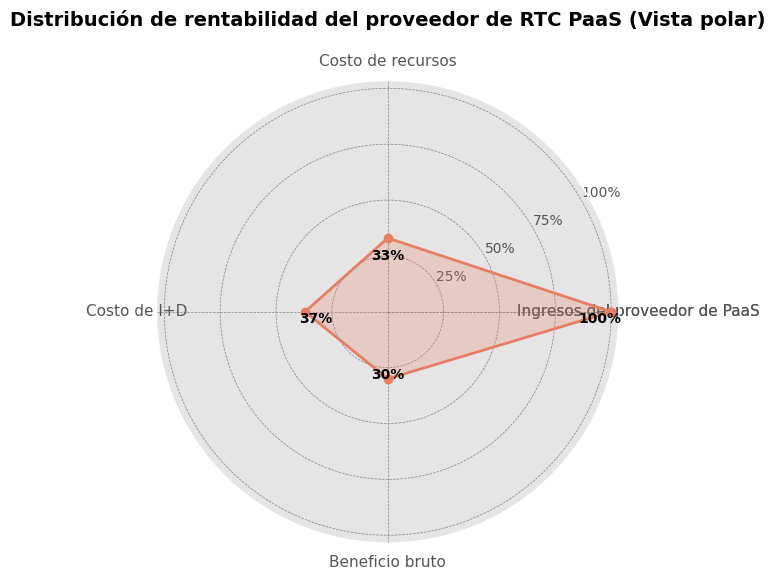

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Establece el estilo y la paleta de colores
plt.style.use("ggplot")
sns.set_palette("Set2")

# Datos
categorias = ["Ingresos del proveedor de PaaS", "Costo de recursos", "Costo de I+D", "Beneficio bruto"]
datos = [100, 33, 37, 30]
colores = sns.color_palette("flare", len(datos))  # Esquema de colores de gradiente brillante

# Gráfico polar (una variante del gráfico de radar) - solo una dimensión, también se puede simular con un gráfico circular
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Ángulos polares
angulos = np.linspace(0, 2 * np.pi, len(datos), endpoint=False).tolist()
# Cierra la forma
datos += datos[:1]
angulos += angulos[:1]

# Graficando
ax.fill(angulos, datos, color=colores[0], alpha=0.25)
ax.plot(angulos, datos, color=colores[0], linewidth=2, linestyle="-", marker='o')

# Agrega etiquetas de datos
for angulo, valor, etiqueta in zip(angulos[:-1], datos[:-1], categorias):
    ax.text(
        angulo,
        valor - 5,  # Desplaza hacia afuera un poco para evitar superposición con el gráfico, ajustable
        f"{valor}%",
        ha='center',
        va='top',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Establece etiquetas de categorías
categorias += categorias[:1]
ax.set_xticks(angulos)
ax.set_xticklabels(categorias, fontsize=11)

# Establece el título
plt.title("Distribución de rentabilidad del proveedor de RTC PaaS (Vista polar)", fontsize=14, fontweight="bold", pad=20)

# Configura el rango del eje
ax.set_rlabel_position(30)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=10)
ax.grid(color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

# 文件: chart_68_2.py

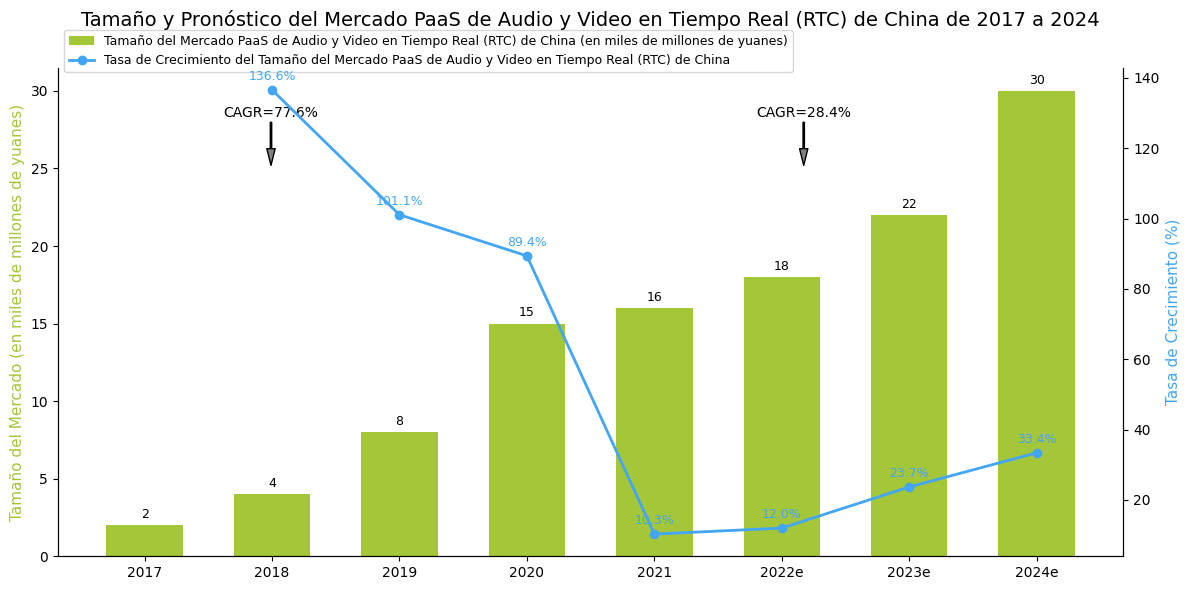

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos simulados (coherentes con la tendencia del gráfico original)
años = ["2017", "2018", "2019", "2020", "2021", "2022e", "2023e", "2024e"]
tamaño_del_mercado = np.array([2, 4, 8, 15, 16, 18, 22, 30])  # Tamaño del mercado (en miles de millones de yuanes)
tasa_de_crecimiento = np.array([136.6, 101.1, 89.4, 10.3, 12.0, 23.7, 33.4])  # Tasa de crecimiento (%)

# Inicializar un lienzo de doble eje
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Dibujar un gráfico de barras (tamaño del mercado)
x = np.arange(len(años))
ancho_de_barra = 0.6
rects = ax1.bar(x, tamaño_del_mercado, width=ancho_de_barra, label="Tamaño del Mercado PaaS de Audio y Video en Tiempo Real (RTC) de China (en miles de millones de yuanes)", color="#A4C639")

# Dibujar un gráfico de línea (tasa de crecimiento)
line, = ax2.plot(x[1:], tasa_de_crecimiento, marker="o", color="#42A5F5", label="Tasa de Crecimiento del Tamaño del Mercado PaaS de Audio y Video en Tiempo Real (RTC) de China", linewidth=2)

# Agregar anotaciones del tamaño del mercado (encima del gráfico de barras)
for rect in rects:
    altura = rect.get_height()
    ax1.annotate(f'{altura}', 
                 xy=(rect.get_x() + rect.get_width()/2, altura),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# Agregar anotaciones de la tasa de crecimiento (encima de los puntos del gráfico de línea)
for i, tasa in enumerate(tasa_de_crecimiento):
    ax2.annotate(f'{tasa}%', 
                 xy=(x[i+1], tasa),  # x comienza en 2018 (índice 1)
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color="#42A5F5")

# Agregar anotaciones de CAGR
ax1.annotate(
    "CAGR=77.6%", 
    xy=(0.2, 0.8), xycoords="axes fraction",
    xytext=(0.2, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)
ax1.annotate(
    "CAGR=28.4%", 
    xy=(0.7, 0.8), xycoords="axes fraction",
    xytext=(0.7, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)

# Configuración de ejes y leyenda
ax1.set_xticks(x)
ax1.set_xticklabels(años, fontsize=10)
ax1.set_ylabel("Tamaño del Mercado (en miles de millones de yuanes)", fontsize=11, color="#A4C639")
ax2.set_ylabel("Tasa de Crecimiento (%)", fontsize=11, color="#42A5F5")

# 组合图例并设置为纵向排列（ncol=1）
handles, labels = ax1.get_legend_handles_labels()
handles.append(line)
labels.append(line.get_label())
# 调整图例位置，避免与标题或图表重叠
ax1.legend(handles, labels, loc="upper left", bbox_to_anchor=(0, 1.09), ncol=1, fontsize=9)

# Título y mejora visual
plt.title("Tamaño y Pronóstico del Mercado PaaS de Audio y Video en Tiempo Real (RTC) de China de 2017 a 2024", fontsize=14, pad=30)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
# 调整布局，为纵向图例留出空间
plt.subplots_adjust(left=0.15)  # 增加左侧边距，避免图例文本被截断
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# 文件: chart_68_3.py

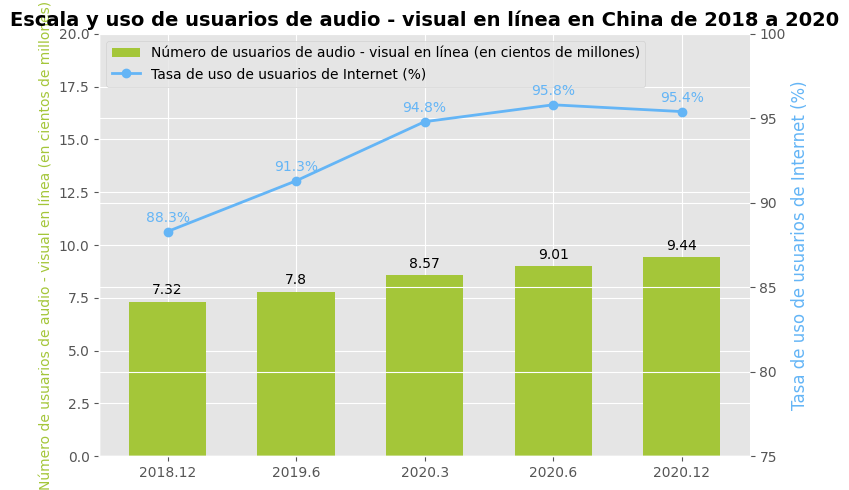

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Nodos de tiempo
años = ["2018.12", "2019.6", "2020.3", "2020.6", "2020.12"]
# Número de usuarios de audio - visual en línea (en cientos de millones)
escala_usuarios = [7.32, 7.8, 8.57, 9.01, 9.44]
# Tasa de uso de usuarios de Internet (%)
tasa_uso = [88.3, 91.3, 94.8, 95.8, 95.4]

# Crear un lienzo y subgráficos con un eje y doble
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.set_ylim(0, 20)  # Eje y para el número de usuarios (en cientos de millones)
ax2.set_ylim(75, 100)  # Eje y para la tasa de uso (%)

# Dibujar un gráfico de barras del número de usuarios de audio - visual en línea
x = np.arange(len(años))
ancho_barra = 0.6
barras = ax1.bar(x, escala_usuarios, width=ancho_barra, color="#A4C639", label="Número de usuarios de audio - visual en línea (en cientos de millones)")

# Dibujar un gráfico de línea de la tasa de uso de usuarios de Internet
linea, = ax2.plot(x, tasa_uso, marker='o', color="#64B5F6", label="Tasa de uso de usuarios de Internet (%)", linewidth=2)

# Agregar etiquetas de datos para el número de usuarios
for barra in barras:
    altura = barra.get_height()
    ax1.annotate(f'{altura}',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 3),  # Ajustar la posición de la etiqueta
                 textcoords="offset points",
                 ha='center', va='bottom')

# Agregar etiquetas de datos para la tasa de uso
for x_val, y_val in zip(x, tasa_uso):
    ax2.annotate(f'{y_val}%',
                 xy=(x_val, y_val),
                 xytext=(0, 5),  # Ajustar la posición de la etiqueta
                 textcoords="offset points",
                 ha='center', va='bottom',
                 color="#64B5F6")

# Establecer las marcas y etiquetas del eje x
ax1.set_xticks(x)
ax1.set_xticklabels(años)
# Establecer las etiquetas del eje y
ax1.set_ylabel("Número de usuarios de audio - visual en línea (en cientos de millones)", color="#A4C639", fontsize=10)
ax2.set_ylabel("Tasa de uso de usuarios de Internet (%)", color="#64B5F6")
# Establecer el título
ax1.set_title("Escala y uso de usuarios de audio - visual en línea en China de 2018 a 2020", fontsize=14, fontweight="bold")

# Combinar leyendas
handles, labels = ax1.get_legend_handles_labels()
handles.append(linea)
labels.append(linea.get_label())
ax1.legend(handles, labels, loc='upper left')

# Embelezar el gráfico ocultando los bordes superior y derecho (para ax1 y ax2)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.tight_layout()  # Ajustar automáticamente el diseño
plt.show()